In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/booking_reviews.csv")

print(df.shape)

df.head()

(26675, 16)


,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b..."
2,2,Exceptional,3 January 2020,Virginia,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~Couple~Apartment with Sea View~St...,"{'language': 'en-gb', 'source': 'https://www.b..."
3,3,My stay in the house was a experiencing bliss ...,8 September 2019,Kannan,NaN,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,"<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
4,4,One bedroom apartment with wonderful view and ...,23 June 2019,Sue,https://cf.bstatic.com/xdata/images/xphoto/squ...,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,South Africa,9.2,The building itself has a very musty smell in ...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~People with friends~Apartment wit...,"{'language': 'en-gb', 'source': 'https://www.b..."


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26675 entries, 0 to 26674
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            26675 non-null  int64  
 1   review_title     26674 non-null  str    
 2   reviewed_at      26570 non-null  str    
 3   reviewed_by      26570 non-null  str    
 4   images           938 non-null    str    
 5   crawled_at       26386 non-null  str    
 6   url              26386 non-null  str    
 7   hotel_name       26386 non-null  str    
 8   hotel_url        26386 non-null  str    
 9   avg_rating       26386 non-null  float64
 10  nationality      26370 non-null  str    
 11  rating           26386 non-null  float64
 12  review_text      26386 non-null  str    
 13  raw_review_text  26202 non-null  str    
 14  tags             26202 non-null  str    
 15  meta             26202 non-null  str    
dtypes: float64(2), int64(1), str(13)
memory usage: 48.9 MB


In [10]:
df.shape

(26675, 16)

In [11]:
df.isnull().sum()

index                  0
review_title           1
reviewed_at          105
reviewed_by          105
images             25737
crawled_at           289
url                  289
hotel_name           289
hotel_url            289
avg_rating           289
nationality          305
rating               289
review_text          289
raw_review_text      473
tags                 473
meta                 473
dtype: int64

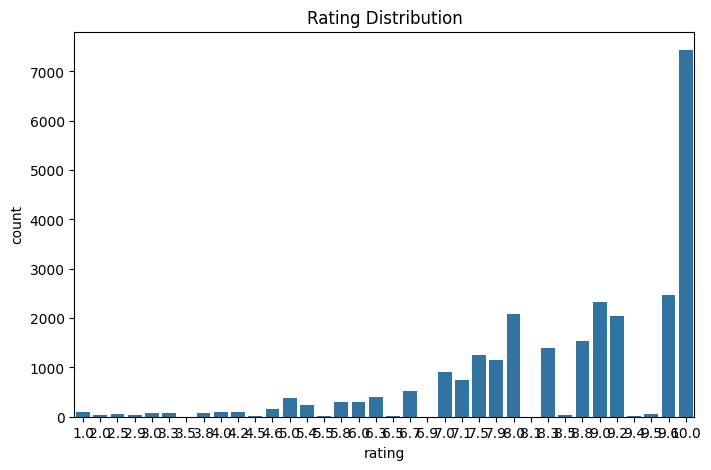

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rating',
    data=df
)

plt.title("Rating Distribution")

plt.show()

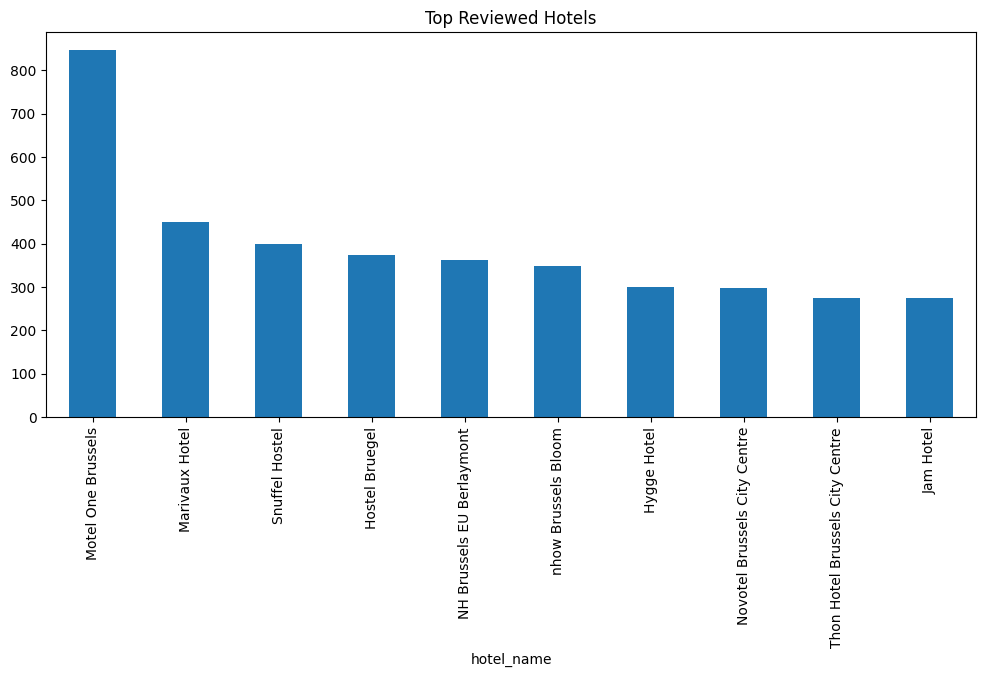

In [13]:
top_hotels = (
    df['hotel_name']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

top_hotels.plot(
    kind='bar'
)

plt.title(
    "Top Reviewed Hotels"
)

plt.show()

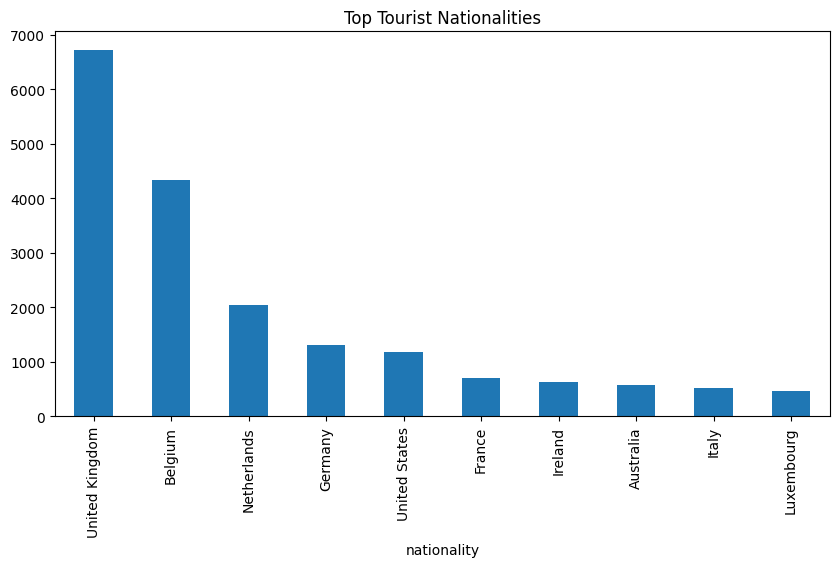

In [14]:
top_country = (
    df['nationality']
    .value_counts()
    .head(10)
)

plt.figure(
    figsize=(10,5)
)

top_country.plot(
    kind='bar'
)

plt.title(
    "Top Tourist Nationalities"
)

plt.show()

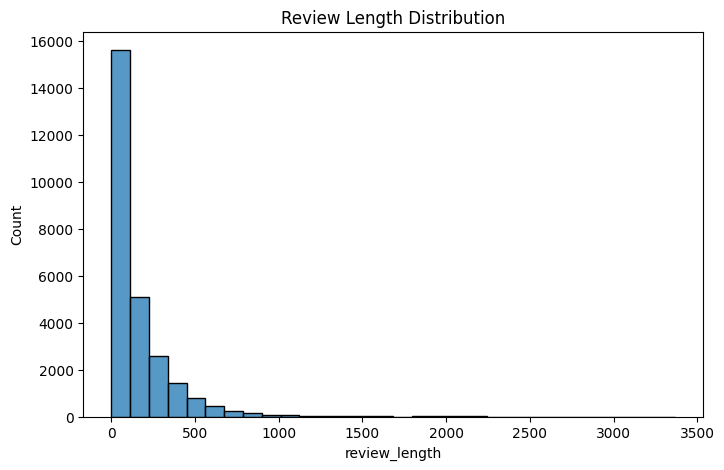

In [18]:
df['review_length'] = (
    df['review_text']
    .fillna("")      # replace missing values
    .astype(str)     # convert everything to text
    .str.len()       # calculate length
)

plt.figure(figsize=(8,5))

sns.histplot(
    df['review_length'],
    bins=30
)

plt.title("Review Length Distribution")

plt.show()

In [16]:
hotel_rating = (
    df.groupby(
        'hotel_name'
    )['rating']
    .mean()
)

hotel_rating.sort_values(
    ascending=False
).head(10)

hotel_name
appartement stylé dans maison bourgeoise    10.0
Hotel Neuvice                               10.0
Villa Anna                                  10.0
The Pearl                                   10.0
Le Cabri Ô Lait                             10.0
De Waterkriek                               10.0
Castelsuites                                10.0
B&B De Swaenhoeck                           10.0
Château Charles                             10.0
Wetterdelle                                 10.0
Name: rating, dtype: float64

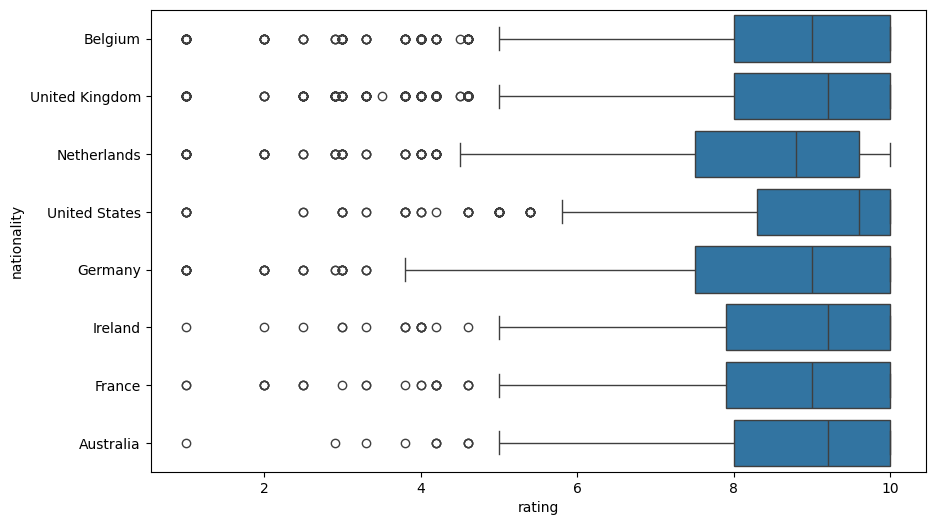

In [17]:
plt.figure(
    figsize=(10,6)
)

sns.boxplot(
    x='rating',
    y='nationality',
    data=df[
        df['nationality']
        .isin(
            df['nationality']
            .value_counts()
            .head(8)
            .index
        )
    ]
)

plt.show()